# Toward Precision Continuing Care

Predicting Lapse Risk in Substance Use Disorders Using Machine Learning

Kendra Wyant [](https://orcid.org/0000-0002-0767-7589)  
March 27, 2026

In [ ]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))

path_models_lag <- format_path(str_c("risk/models/lag"))
path_processed <- format_path("risk/data_processed/lag")
path_models_risk2 <- format_path("risk2/models/combined")

options(knitr.kable.NA = '')

In [ ]:
# read in tibbles for in-line code

test_metrics_all_pp_perf <- read_csv(here::here(path_models_lag, 
                                                "pp_perf_tibble.csv"), 
                                     col_types = cols())

ci_baseline <- read_csv(here::here(path_models_lag, "contrast_baseline.csv"), 
                        col_types = cols())

ci_lag <- read_csv(here::here(path_models_lag, "contrast_adjacent.csv"), 
                   col_types = cols())

pp_dem <- read_csv(here::here(path_models_lag, "pp_dem_all.csv"), col_types = cols())

pp_dem_contrast <- read_csv(here::here(path_models_lag, "pp_dem_contrast_all.csv"), col_types = cols())

screen <- read_csv(here::here(path_processed, "dem_tibble.csv"),
                   col_types = cols())

lapses_per_subid <- read_csv(here::here(path_processed, "lapse_tibble.csv"),
                             col_types = cols())


pp_perf <- read_csv(here::here(path_models_risk2, "pp_perf_tibble_v10.csv"),
                    show_col_types = FALSE) 

probs <- read_rds(here::here(path_models_risk2, "preds_1_x_5_day_v10_kfold_full_final.rds"))

# Introduction

## Substance Use Disorders

In 2024, over 46 million U.S. adults had a substance use disorder (SUD) in the past year \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed\]. SUDs are associated with high rates of morbidity and mortality. Opioid overdose rates remain high and continue to increase each year \[@IncreasesDrugOpioid; @friedmanTrendsDrugOverdose2022\]. Excessive alcohol use is a leading preventable cause of death, with the majority of these deaths caused by alcohol-attributed cancer, heart problems and stroke, and liver cirrhosis \[@ARDIAlcoholAttributableDeaths\]. Additionally, alcohol-impaired driving accounts for over 30% of traffic fatalities each year \[@unitedstatesdepartmentoftransportationnationalhighwaytrafficsafetyadministrationnationalcenterforstatisticsandanalysisTrafficSafetyFacts2024\].

The economic cost of SUDs is substantial. In 2016 the economic cost associated with SUDs was estimated to exceed \$442 billion in lost productivity, health care expenses, law enforcement, and other criminal justice costs \[@substanceabuseandmentalhealthservicesadministrationusFacingAddictionAmerica2016\]. When also accounting for costs associated with loss of life and reduced quality of life, one research group estimated that in 2017 the cost of opioid use disorder alone exceeded \$1 trillion \[@florenceEconomicBurdenOpioid2021\].

SUDs are chronic, relapsing conditions \[@mclellanDrugDependenceChronic2000; @mckayImpactContinuingCare2021\]. Effective pharmacological and psychosocial interventions exist to support symptom stabilization and reduce substance use \[@bowenMindfulnessBasedRelapsePrevention2021; @marlattRelapsePreventionSecond2007; @lieseCognitiveBehavioralTherapyAddictive2022\]. Despite the availability of effective treatments, the majority of individuals with SUDs do not receive care. In 2023, less than 15% of individuals with an SUD received any form of treatment, a stark comparison to treatment initiation for other chronic diseases \[@substanceabuseandmentalhealthservicesadministration2024NSDUHDetailed. Even among the minority who do initiate treatment, engagement is often brief and episodic. Relapse back to substance use is common, particularly in the absence of continued treatment engagement and recovery support. Importantly, relapse rates for SUDs are comparable to recurrence rates in other chronic conditions (e.g., type I diabetes, hypertension, asthma) when medication adherence and follow-up care are inconsistent. Thus, the recurrence of symptoms is not unique to SUDs but rather a challenge inherent in chronic disease management without adequate continuing care.

These patterns reflect structural limitations within the current treatment system. Several factors, including cost and insurance reimbursement issues, lack of collaborative provider teams, passive referral processes, geographic barriers to accessing services, patient dropout, and changes in the patient’s clinical needs over time, suggest our current treatment system for SUDs does not have the capacity for long-term clinician-delivered care \[@dennisManagingAddictionChronic2007; @taiTreatmentSubstanceUse2013; @mckayImpactContinuingCare2021; @stanojlovicTargetingBarriersSubstance2021\]. Stigma surrounding SUD and historical views of substance use as a social or behavioral problem have contributed to the siloing of SUD care. Treatment typically occurs in specialized, community-based settings that are disconnected from primary care. This fragmented infrastructure results in poor care coordination, missed opportunities for early intervention and re-engagement, and a “revolving door” pattern in which individuals cycle repeatedly through acute episodes of care as opposed to receiving long-term chronic disease management.

## Disparities in SUD Treatment Access and Outcomes

Limitations of the current SUD treatment infrastructure are magnified for people with certain identities. Women, low income individuals, rural residents, and older adults may face unique barriers to treatment, including financial constraints, limited service availability, and mobility or transportation challenges. Marginalized groups, such as racial, ethnic, and sexual minorities may additionally experience minority stress, stigma, discrimination, and isolation leading to higher rates of SUD and poorer treatment outcomes.

Black and Hispanic individuals are less likely to receive treatment and are more likely to experience negative consequences associated with SUDs \[@pinedoCurrentReexaminationRacial2019; @guerreroDisparitiesLatinoSubstance2013; @schmidtEthnicDisparitiesClinical2007; @kilaruIncidenceTreatmentOpioid2020\]. Among those who do receive treatment, dropout rates are higher compared to non-Hispanic White individuals \[@salonerBlacksHispanicsAre2013\]. Hispanic and non-White individuals are also more likely to face socioeconomic barriers, including unemployment and housing instability.

Sexual minority populations experience disproportionately high rates of SUD compared to heterosexual populations \[@freitagVariationsSubstanceUse2021; @craneAlcoholUseDisorders2020\]. Some research suggests that these elevated rates are related to depleted coping mechanisms resulting from chronic minority stress and enacted stigma (e.g., discrimination, biased treatment, microaggressions) \[@dyarSexualMinorityStress2023; @kruegerSexualOrientationDisparities2020\]. These disparities intensify when sexual orientation intersects with other identities such as race or gender \[@freitagVariationsSubstanceUse2021; @kerridgePrevalenceSociodemographicCorrelates2017\].

Women are less likely than men to enter treatment \[@greenfieldSubstanceAbuseTreatment2007; @kilaruIncidenceTreatmentOpioid2020\] and more frequently experience barriers related to unemployment, financial dependence, psychiatric comorbidities, and childcare responsibilities. Women who are pregnant or have children often report avoiding treatment because they fear losing custody or having their baby removed \[@greenfieldSubstanceAbuseTreatment2007; @parlier-ahmadExploratoryStudySex2021\]. Women are also more vulnerable to adverse health and social consequences of SUDs \[@mchughSexGenderDifferences2018\]. They typically show an accelerated progression from onset of use to treatment entry and develop severe symptoms over fewer years compared to men \[@campbellBriefReportGender2018\].

Low-income individuals face heightened risk for developing SUD and greater challenges accessing treatment. Prior to the 2014 Affordable Care Act, financial barriers prevented many low-income individuals from accessing SUD treatment. The Affordable Care Act expanded Medicaid eligibility to include nearly all low-income individuals, broadening access to government-funded SUD treatment services. This expansion has also been shown to reduce racial and ethnic disparities in access to care, as minorities are disproportionately represented among low-income populations \[@cookRacialethnicDisparitiesSubstance2011\]. Nevertheless, low income remains associated with higher rates of SUD, more severe SUD, and co-occurence with socioenvironmental risk factors that can interfere with treatment and recovery \[@grantEpidemiologyDSM5Alcohol2015b\].

Rural areas have higher SUD prevalence yet fewer treatment clinics and providers \[@listerSystematicReviewRuralspecific2020\]. This imbalance results in a disproportionate SUD burden for rural residents, including elevated opioid overdose rates and treatment waitlists that may last months to years \[@sigmonAccessTreatmentOpioid2014\]. For individuals who do get treatment, services are often not near by. The time and financial costs associated with travel contribute to missed appointments and early treatment dropout. This is especially true for individuals receiving medication for OUD, who often must attend daily clinic visits for observed dosing. Stigma surrounding SUD treatment may also be higher in small rural communities where services are more visible and harder to access discreetly \[@woodLotPeopleCall2019\].

Older adults (65+) are less likely to receive SUD treatment or perceive a need for treatment compared to younger age groups \[@choiTreatmentUsePerceived2014; @kilaruIncidenceTreatmentOpioid2020\]. They are also more likely to experience complicating factors such as medical comorbidities, chronic pain and heightened sensitivity to medication interactions and side effects \[@kuerbisSubstanceAbuseOlder2014; Salive\]. Additionally, factors such as being divorced or widowed, retired, or having fewer social activities may reduce opportunities for family or friends to notice harmful substance use. Doctors and clinicians may also attribute SUD symptoms to other health or age-related issues.

## Relapse Prevention

Recovery from substance use disorders is a non-linear and dynamic process \[@witkiewitzRelapsePreventionAlcohol2004\]. Lapses back to substance use are common and, on their own, do not necessarily constitute relapse (i.e., a full return to problematic use). Nevertheless, lapses must precede relapse and therefore can be viewed as early warning signs, making them clinically meaningful targets for intervention and prevention.

An extant relapse prevention literature has identified a range of intrapersonal precursors to lapse and relapse. These include self‑efficacy (i.e., confidence in one’s ability to maintain abstinence), craving, motivation, emotional states, and coping‑related or substance‑use behaviors \[@witkiewitzRelapsePreventionAlcohol2004; @witkiewitzTherapistsGuideEvidenceBased2007; @marlattRelapsePreventionSecond2007\]. These risk factors differ across individuals and within an individual over time. They interact with one another and with interpersonal and environmental situations to influence lapse risk \[@stantonRelapsePreventionNeeds2005a; @witkiewitzRelapsePreventionAlcohol2004\]. For example, cravings are typically short-lived urges. Individuals in recovery-supportive environments may be able to ride out these cravings successfully. However, in unsupportive environments (e.g., locations with easily available alcohol or exposure to other substance-related cues), the likelihood of lapse increases. Given the complex, interactive, and time-varying nature of lapse risk, self-monitoring is difficult.

## Recovery Monitoring and Support System

An algorithm-guided recovery monitoring and support system could help individuals monitor their current and future risk of lapse and make adjustments in their activities and supports to meet their recovery goals after initial treatment. Such a tool could offer personalized, adaptive recommendations aligned with evidenced-based care and prompt individuals to engage with support at times of high risk. For example, individuals could receive daily messages about changes in their lapse risk and receive personalized recommendations based on top features contributing to their risk. Moreover, it would provide a scalable option for long-term monitoring and support to address the substantial unmet need for continuing care for SUDs.

For such a system to exist, at least three pre-requisites must be met. One, the system must be able to collect a rich and densely sampled source (or sources) of risk-relevant data. Two, the system must have access to a model that can predict substance use with high performance and temporal precision and have interpretable model inputs for support recommendations to be mapped onto. Three, the model must perform fairly. The accuracy of the predictions and usefulness and relevance of the recommendations should be similar for everyone. Advances in both smartphone sensing \[@mohrPersonalSensingUnderstanding2017\] and machine learning \[@hastieElementsStatisticalLearning2009\] now make this possible.

Smartphone sensing approaches (e.g., ecological momentary assessment \[EMA\], geolocation sensing) can provide the frequent, longitudinal measurement of proximal risk factors that is necessary for prediction of future lapses with high temporal precision. Individuals with substance use disorders have demonstrated a willingness to provide EMA over extended periods of time with adequate adherence \[@jonesComplianceEcologicalMomentary2019; @alexanderUseEcologicalMomentary2023; @wyantAcceptabilityPersonalSensing2023\]. Individuals with alcohol use disorder who provided geolocation data for up to three months reported generally finding this sensing method acceptable and being willing to provide the data for up to a year \[@wyantAcceptabilityPersonalSensing2023\]. Moreover, the proliferation of smartphone usage in recent years makes smartphone sensing a potentially scalable and equitable method for improving lapse risk monitoring. As of 2025, roughly 91% of Americans own a smartphone and smartphone ownership is consistently high (\>= 85%) across gender, race and ethnicity, socioeconomic status, and geographic location \[@pewresearchcenterDemographicsMobileDevice2025\].

Machine learning models can handle the high dimensional feature sets that may result from feature engineering densely sampled sensing data over time. They can also accommodate non-linear and interactive relationships between features and lapse probability. And methods from interpretable machine learning can be used to understand which risk features contribute most strongly to a lapse prediction for a specific individual at a specific moment in time. Studies have begun to demonstrate how sensing features can be used to predict substance use with high accuracy \[@baeMobilePhoneSensors2018; @waltersUsingMachineLearning2021; @baeLeveragingMobilePhone2023; @soysterPooledPersonspecificMachine2022; @heinzLongitudinalObservationalStudy2025\]. While these studies are promising, they are limited in their generalizability to a recovery monitoring and support system. First, the majority of these studies predict substance use episodes in non-treatment seeking populations \[@baeMobilePhoneSensors2018; @baeLeveragingMobilePhone2023; @waltersUsingMachineLearning2021; @soysterPooledPersonspecificMachine2022\]. The precursors to goal-inconsistent substance use (i.e., lapses) in populations with substance use disorder may vastly differ from planned or intentional substance use episodes. Second, none of these studies explicitly assessed the fairness of the machine learning models. An automated recovery monitoring and support system offers opportunity for mitigating many of the accessibility, affordability, and stigma barriers that contribute to treatment disparities. However, algorithms that perform favorably for only a single majority group could widen existing disparities in access to resources and important clinical outcomes \[@timmonsCallActionAssessing2023\].

## Specific Aims

This dissertation presents a series of studies aimed at addressing current limitations in the lapse prediction literature. Specifically, we designed three studies to develop fair and temporally precise machine learning models for predicting lapse risk for alcohol and opioid use that could be used in a recovery monitoring support system.

To achieve this goal, we used two clinical samples of participants in early recovery from alcohol (Studies 1–2) and opioid use (Study 3) disorders with reported goals of abstinence. In Study 1 (Chapter 2), we developed three separate models that provide hour-by-hour probabilities of a future lapse back to alcohol use with increasing temporal precision: lapses in the next week, next day, and next hour. Model features were engineered from raw scores and longitudinal changes in responses to 4× daily EMAs. We used Shapley values to interpret how EMA features influenced lapse probability both across individuals and for specific lapse probability predictions.

In Study 2 (Chapter 3), we demonstrated how the same 4× daily EMA data could be used to predict alcohol lapses occurring within a 24-hour window up to two weeks into the future. We examined several lags between the prediction time point and the start of the prediction window: 1 day, 3 days, 1 week, and 2 weeks. These models with lagged prediction windows provide insight into lapse risk with the added benefit of advanced warning, giving individuals extra time to make behavioral, social, or lifestyle changes. Study 2 also extended model evaluation to include fairness analyses by comparing model performance across subgroups with documented disparities in treatment access and outcomes.

In Study 3 (Chapter 4), we extended lapse prediction to opioid use using a national sample of participants with opioid use disorder. This allowed us to evaluate whether lapse prediction algorithms generalize beyond alcohol to substances where use is illegal and lapses may be underreported. The dataset also included greater diversity in race/ethnicity, income, and geographic location (i.e., rural and urban settings), enabling evaluation of model fairness across a broader set of demographic groups. Model features were derived from both 1× daily EMA and passive geolocation sensing, capturing self-reported risk factors as well as behavioral patterns such as time spent in potentially high-risk locations and changes in routine. We also explored alternative methods for quantifying important features that could be communicated to individuals to explain lapse risk.

# Machine learning models for temporally precise lapse prediction in alcohol use disorder

## Introduction

Over 30 million adults in the United States (US) had an active alcohol use disorder (AUD) in 2021, and 23.3% reported engaging in past-month binge drinking \[@samhsacenterforbehavioralhealthstatisticsandquality2021NSDUHDetailed2021\]. Alcohol ranks as the third leading preventable cause of death in the US, accounting for approximately 140,000 fatalities \[@centersfordiseasecontrolandpreventioncdcAnnualAverageUnited\] and economic costs that exceed \$249 billion annually \[@substanceabuseandmentalhealthservicesadministrationusFacingAddictionAmerica2016\].

Existing clinician-delivered treatments for AUD that were derived from Marlatt’s relapse prevention model \[@marlattRelapsePreventionMaintenance1985\] are effective when delivered (e.g., cognitive-behavioral therapy, mindfulness-based relapse prevention \[@bowenRelativeEfficacyMindfulnessBased2014\]). Unfortunately, fewer than 1 in 20 adults with an active AUD receive any treatment \[@samhsacenterforbehavioralhealthstatisticsandquality2021NSDUHDetailed2021\]. Even more concerning, failure to access treatment is associated with demographic factors including race, ethnicity, geographic region, and socioeconomic status, which further increase mental health disparities \[@officeofthesurgeongeneralusMentalHealthCulture2001\]. This treatment gap and associated disparities stem from well-known barriers to receiving clinician-delivered mental healthcare related to affordability, accessibility, availability, and acceptability \[@jacobsonDigitalTherapeuticsMental2022\].

Digital therapeutics may help to overcome these barriers associated with in-person, clinician-delivered treatments. Digital therapeutics provide evidence-based interventions and other supports via smartphones to prevent, treat, or manage a medical disorder, either independently or in conjunction with traditional treatments \[@jacobsonDigitalTherapeuticsMental2022\]. They offer highly scalable, on-demand therapeutic support that is accessible whenever and wherever it is needed most. Several large, randomized controlled trials have confirmed that digital therapeutics for AUD improve clinical outcomes \[@gustafsonSmartphoneApplicationSupport2014; @campbellInternetdeliveredTreatmentSubstance2014; @jacobsonDigitalTherapeuticsMental2022\]. Additionally, US adults (including patients with AUD \[@wyantAcceptabilityPersonalSensing2023\]) display high rates of smartphone ownership (over 85% in 2021), with minimal variation across race, ethnicity, socioeconomic status, and geographic settings. Therefore, digital therapeutics may not only mitigate in-person treatment barriers but also combat associated disparities \[@jacobsonDigitalTherapeuticsMental2022\].

### Improving Digital Therapeutics via Personal Sensing

Despite the documented benefits of digital therapeutics, their full potential has not yet been realized. Patients often don’t engage with digital therapeutics as developers intended, and long-term engagement may not be sustained or matched to patients’ needs \[@hatchExpertConsensusSurvey2018; @jacobsonDigitalTherapeuticsMental2022\]. The substantial benefits of digital therapeutics come from easy, 24/7 access to their intervention and other support modules. However, the burden falls primarily on the patient to identify the most appropriate modules for them in that specific moment during their recovery.

This difficulty is magnified by the dynamic, chronic, and relapsing nature of AUD \[@brandonRelapseRelapsePrevention2007\]. Numerous risk and protective factors interact in complex, non-linear ways to influence the probability, timing, and severity of relapse (i.e., a goal-inconsistent return to frequent, harmful alcohol use) \[@witkiewitzModelingComplexityPosttreatment2007\]. Factors such as urges, mood, lifestyle imbalances, self-efficacy, and motivation can all vary over time. Social networks may evolve to become more protective or risky, and high-risk situations can arise unexpectedly. Consequently, both relapse risk and the factors driving that risk fluctuate over time.

Successful, continuous monitoring of risk for relapse and its contributing factors would enable patients to adapt their lifestyle, behaviors, and supports to their changing needs. Successful monitoring could also direct patients to engage with the most appropriate digital therapeutic modules, addressing the unique risks present at any given moment throughout their recovery. Such continuous monitoring is now feasible via personal sensing (i.e., in-situ data collection via sensors embedded in individuals’ daily lives) \[@epsteinPredictionStressDrug2020; @soysterPooledPersonspecificMachine2022; @moshontzProspectivePredictionLapses2021; @wyantAcceptabilityPersonalSensing2023; @chihPredictiveModelingAddiction2014; @baeMobilePhoneSensors2018\].

The current study focuses explicitly on using ecological momentary assessment (EMA) for monitoring risk of return to alcohol use. EMA can be easily implemented with only a smartphone. Moreover, comparable item responses can be collected consistently across different hardware and operating systems. Thus, EMA can be incorporated essentially identically into any existing or future smartphone-based digital therapeutic. EMA, like other personal sensing methods, can support the frequent, in-situ, longitudinal measurement necessary for monitoring fluctuating relapse risk. Long-term monitoring with EMA has been well-tolerated by individuals with AUD \[@wyantAcceptabilityPersonalSensing2023\]. Additionally, previous research has validated the use of EMA to measure known risk and protective factors for relapse, including craving \[@dulinSmartphonebasedMomentaryIntervention2017\], mood \[@russellAffectRelativeDayLevel2020\], stressors, positive life events \[@dvorakTensionReductionAffect2018\], and motivation/efficacy \[@dvorakEcologicalMomentaryAssessment2014\]. EMA offers privileged access into these and other subjective factors that may be difficult to quantify reliably through other sensing methods.

### Promising Preliminary Research

Preliminary research is now emerging that uses EMA responses as features in machine learning models to predict the probability of future alcohol use \[@baeMobilePhoneSensors2018; @soysterPooledPersonspecificMachine2022; @waltersUsingMachineLearning2021; @chihPredictiveModelingAddiction2014\]. This research is important because it rigorously required strict temporal ordering necessary for true prediction, with features measured before alcohol use outcomes. It also used resampling methods (e.g., cross-validation) that prioritize model generalizability to increase the likelihood these models will perform well with new people.

Despite this initial promise, several important limitations exist. Some prediction models have been trained using convenience samples (e.g., college students) \[@soysterPooledPersonspecificMachine2022; @baeMobilePhoneSensors2018\]. Other models have been developed to predict hazardous alcohol use in non-treatment-seeking populations \[@waltersUsingMachineLearning2021\]. In both these instances, features that predict planned or otherwise intentional alcohol use among individuals not motivated to change their behavior may not generalize to people in AUD recovery. Moreover, individuals who have not yet begun to contemplate and/or commit to behavior change regarding their alcohol use are unlikely to use digital therapeutics designed for AUD recovery \[@prochaskaSearchHowPeople1992\].

A handful of other models have been trained to predict putative precursors of substance use, such as craving \[@burgess-hullTrajectoriesCravingMedicationassisted2022; @dumortierClassifyingSmokingUrges2016\] and stress \[@epsteinPredictionStressDrug2020\]. Although craving and stress may be associated with substance use, their relationships with relapse are complex, inconsistent, and not always very strong \[@fronkStressAllostasisSubstance2020; @sayetteRoleCravingSubstance2016\]. For these reasons, we believe that explicit substance use may be a better target for prediction.

With respect to explicit substance use, we also argue that models that predict lapses (i.e., single instances of goal-inconsistent substance use) rather than relapse may be preferred. Lapses are clearly defined, observable, and have temporally precise onsets and offsets. Conversely, definitions of relapse vary widely \[@witkiewitzModelingComplexityPosttreatment2007\], and it is difficult to delineate precisely when relapse begins or ends. Lapses always precede relapse and therefore may serve as an early warning sign for intervention. Finally, maladaptive responses to a lapse (e.g., abstinence violation effects; \[@marlattRelapsePreventionMaintenance1985\]) can undermine recovery by themselves, making lapses clinically meaningful events to detect and address.

An early alcohol lapse prediction model developed by Gustafson and colleagues \[@chihPredictiveModelingAddiction2014\] provided the foundation on which our current project builds. Participants completed EMAs once per week for 8 months while using a digital therapeutic after discharge from an inpatient treatment program for AUD. These EMAs were used as features in a machine learning model to predict lapses. However, the temporal precision for both the features and outcome was coarse. Model predictions were updated only once per week at most, and lapse onsets could occur anytime within the next two weeks. This coarseness restricts the model from being used to implement *just-in-time* interventions (e.g., guided mindfulness or other stress reduction techniques, urge surfing) that are well-suited to digital therapeutics.

### The Current Study

The current study addresses these limitations of previously developed prediction models. We trained our models using participants in early recovery from moderate to severe AUD who reported a goal of alcohol abstinence. We developed three separate models that provide hour-by-hour probabilities of a future lapse back to alcohol use with increasing temporal precision: lapses in the next week, next day, and next hour. Model features were engineered from raw scores and longitudinal change in responses to 4X daily EMAs. These features were derived to measure theoretically-implicated risk factors and contexts that have considerable support as predictors of lapses including past use, craving, past pleasant events, past and future risky situations, past and future stressful events, emotional valence and arousal, and self-efficacy \[for reviews, see @marlattRelapsePreventionMaintenance1985; @fronkStressAllostasisSubstance2020; @witkiewitzModelingComplexityPosttreatment2007\].

In this study, we characterize the performance of these three prediction models in held-out data (i.e., for observations from participants who were not used to train the models). We also evaluated the relative feature importance of key relapse prevention constructs in the models as part of the model validation process and to contribute to the relapse prevention literature. This research represents an important step toward the development of a “smart” (machine learning guided) sensing and prediction system that can be embedded within a digital therapeutic both to identify periods of peak lapse risk and to recommend specific supports to address factors contributing to this risk.

## Method

### Transparency and Openness

We adhere to research transparency principles that are crucial for robust and replicable science. We reported how we determined the sample size, all data exclusions, all manipulations, and all study measures. Finally, our data, analysis scripts, annotated results, questionnaires, and other study materials are publicly available (<https://osf.io/w5h9y/>).

Our study design and analyses were not pre-registered. However, we restricted many researcher degrees of freedom via cross-validation. Cross-validation inherently includes replication; models are fit on held-in training sets, decisions are made in held-out validation sets, and final performance is evaluated on held-out test sets.

### Participants

We recruited 151 participants in early recovery (1-8 weeks of abstinence) from AUD in Madison, Wisconsin, US. This sample size was determined based on traditional power analysis methods for logistic regression \[@hsiehSampleSizeTables1989\] because comparable approaches for machine learning models have not yet been validated. Participants were recruited through print and targeted digital advertisements and partnerships with treatment centers. We required participants:

1.  were age 18 or older,
2.  could write and read in English,
3.  had at least moderate AUD (\>= 4 self-reported DSM-5 symptoms),
4.  were abstinent from alcohol for 1-8 weeks, and
5.  were willing to use a single smartphone (personal or study provided) while on study.

We also excluded participants exhibiting severe symptoms of psychosis or paranoia.

### Procedure

Participants completed five study visits over approximately three months. After an initial phone screen, participants attended an in-person screening visit to determine eligibility, complete informed consent, and collect self-report measures. Eligible, consented participants returned approximately one week later for an intake visit. Three additional follow-up visits occurred about every 30 days that participants remained on study. Participants were expected to complete four daily EMAs while on study. Other personal sensing data streams (geolocation, cellular communications, sleep quality, and audio check-ins) were collected as part of the parent grant’s aims (R01 AA024391).

### Measures

#### Ecological Momentary Assessments

Participants completed four brief (7-10 questions) EMAs daily. The first and last EMAs of the day were scheduled within one hour of participants’ typical wake and sleep times. The other two EMAs were scheduled randomly within the first and second halves of their typical day, with at least one hour between EMAs. Participants learned how to complete the EMA and the meaning of each question during their intake visit.

On all EMAs, participants reported dates/times of any unreported past alcohol use. Next, participants rated the intensity of four recent experiences:

- craving \[“How intense was your greatest urge to drink?”\],
- risky situations \[“Did you encounter any risky situations (people, places, or things)? If yes, rate the intensity of the situation.”\],
- stressful events \[“Has a hassle or stressful event occurred? If yes, rate the intensity of the event.”\],
- pleasant events \[Has a pleasant or positive event occurred? If yes, rate the intensity of the event.”\].

For each of these experiences, participants rated the maximum intensity since their last EMA on a 12-point ordinal scale (mid- and end-point anchors of “Mild”, “Moderate”, and “Strong”). If they did not experience an event since their last EMA, participants selected “No” to indicate that no experience occurred for that respective question.

Next, participants rated their current affect using 11-point bipolar scales measuring valence (end-point anchors of “Unpleasant/Unhappy” to “Pleasant/Happy”) and arousal (end-point anchors of “Calm/Sleepy” to “Aroused/Alert”).

On the first EMA each day, participants used an 11-point bipoloar scale (end-point anchors of “Very Unlikely” to “Very Likely”) to rate the likelihood of:

- future risky situations \[“How likely are you to encounter risky situations (people, places, or things) within the next week?”\],
- future stressful events \[“How likely are you to encounter a stressful event within the next week?”\],
- abstinence efficacy \[“How likely are you to drink any alcohol within the next week?”\].

#### Individual Differences

We collected self-report information about demographics (age, sex, race, ethnicity, education, marital status, employment, and income) and clinical characteristics (AUD milestones, number of quit attempts, lifetime AUD treatment history, lifetime receipt of AUD medication, DSM-5 AUD symptom count, and current drug use \[@whoassistworkinggroupAlcoholSmokingSubstance2002\]). This information was collected primarily to characterize the sample and to evaluate the diversity of the training data. We also included demographic features in our models to quantify the importance of relapse prevention constructs beyond these static characteristics, given known disparities in AUD and other health outcomes \[@jacobsonDigitalTherapeuticsMental2022\].

### Data Analytic Strategy

Data preprocessing, modeling, and Bayesian analyses were done in R using the tidymodels ecosystem \[@kuhnTidymodelsCollectionPackages2020\]. Models were trained and evaluated using high-throughput computing resources provided by the University of Wisconsin Center for High Throughput Computing \[@chtc\].

#### Lapse Labels

We predicted future lapses in three prediction window widths: one week, one day, and one hour. Prediction windows were updated hourly. All classification models provide hour-by-hour predictions of future lapse probability for all three window widths.

For each participant, the first prediction window for all three widths began at midnight on their second day of participation and ended one week, one day, or one hour later. This ensured at least 24 hours of past EMAs for future lapse prediction in these first windows. Subsequent windows for each participant were created by repeatedly rolling the window start/end forward one hour until the end of their study participation (i.e., each participant’s last prediction window started one week, one day, or one hour before their last recorded EMA).

We labeled each prediction window as *lapse* or *no lapse* using participants’ reports from the EMA question “Have you drank any alcohol that you have not yet reported?”. If participants answered yes to this question, they entered the date and hour of the start and end of the drinking episode. During monthly follow-up sessions, participants could review and correct their lapses reported by EMA and report to staff any additional lapses.

A prediction window was labeled *lapse* if the start date/hour of any drinking episode fell within that window. A window was labeled *no lapse* if no alcohol use occurred within that window +/- 24 hours. If no alcohol use occurred within the window but did occur within 24 hours of the start or end of the window, the window was excluded. We used this conservative 24-hour fence for labeling windows as *no lapse* (vs. excluded) to increase the fidelity of these labels. Given that most windows were labeled *no lapse*, and the outcome was highly unbalanced, it was not problematic to exclude some *no lapse* events to further increase confidence in those labels.

#### Feature Engineering

Features were calculated using only data collected before the start of each prediction window to ensure our models were making true *future predictions*. We created features for both baseline and full models. The baseline models were developed to determine how well we could predict lapses using a simple model based only on the participants’ histories of previous lapses. The full models used all EMA responses combined with demographic and day/time features.

The baseline models had only one dummy-coded feature: lapse frequency (high vs. low). The median number of lapses across participants during the study period was 1. Therefore, the lapse frequency feature was coded low when the participant had a history of 1 or fewer lapses before that prediction window. This feature was coded high when the participant had more than 1 lapse before that window.

Features for the full model were derived from three sources: 1) common demographic characteristics, 2) day of the week and hour of the day at prediction window onset, and 3) previous EMA responses. We created a quantitative feature for age, and dummy-coded features for sex (male vs. female), race/ethnicity (White/Non-Hispanic vs. other), marital status (never married vs. married vs. other), and education (high school or less vs. some college vs. 4-year degree or more). We created dummy-coded features to indicate time of day (5pm - midnight vs. any other time) and day of week that the prediction window began.

We created raw EMA features for varying scoring epochs before the start of the prediction window for all EMA items excluding the alcohol use question. For the six EMA questions that appeared on all four daily EMAs, we used five scoring epochs of 12, 24, 48, 72, and 168 hours. For the three EMA questions that only appeared on the morning EMA, we used three scoring epochs of 48, 72, and 168 hours. Raw features included min, max, and median scores for each EMA question across all EMAs in each epoch for that participant. We calculated change features by subtracting the participant’s mean score for each EMA question (using all EMAs collected before the start of the prediction window) from the associated raw feature. These change features allowed us to capture within-subject effects by comparing recent EMA responses relative to an individual’s own baseline. For both raw and change features, the feature was set to missing (and later imputed; see below) if no responses to the specific EMA question were provided by the participant within the associated scoring epoch.

We also created raw and change features based on the most recent response for each EMA question (excluding the alcohol use question). This generated two features for each EMA question: 1) raw value of the most recent previous response, and 2) difference between that raw value and the mean response to that EMA question over all EMAs collected before that prediction window.

We also calculated raw and change rate features from previously reported lapses. We calculated lapse rate features using the same five scoring epochs described earlier. Raw lapse rate features were generated by dividing the total number of previously observed lapses within a scoring epoch by the duration of that epoch. For change rate features, we subtracted the rate of previous lapses for that participant (i.e., total number of lapses while on-study divided by total hours on-study before the prediction window) from their associated raw lapse rate. We employed a similar approach to calculate raw and change rate of missing EMAs (i.e., number of full EMA surveys that were requested but not completed in a scoring epoch / duration of epoch).

Other generic feature engineering steps included: 1) imputing missing data (median imputation for numeric features, mode imputation for nominal features); 2) dummy coding for nominal features; and 3) removing zero-variance features. Medians/modes for missing data imputation and identification of zero variance features were derived from held-in (training) data and applied to held-out (validation and test) data (see Cross-validation section below). We recognize that median/mode imputation is a coarse method for handling missing data; however, computational costs of more sophisticated methods (e.g., KNN imputation, multiple imputation) were not practical for this study. A sample feature engineering script (i.e., tidymodels recipe) containing all feature engineering steps is available on our OSF study page.

#### Model Training and Evaluation

##### Statistical Algorithm and Hyperparameters.

We trained and evaluated six separate classification models: one baseline and one full model for each prediction window (week, day, and hour). We initially considered four well-established statistical algorithms (XGBoost, Random Forest, K-Nearest Neighbors, and Elastic Net) that vary across characteristics expected to affect model performance (e.g., flexibility, complexity, handling higher-order interactions natively) \[@kuhnAppliedPredictiveModeling2018\]. However, preliminary exploratory analyses suggested that XGBoost consistently outperformed the other three algorithms. Furthermore, the Shapley Additive Explanations (SHAP) method, which we planned to use for explanatory analyses of feature importance in our full models, is optimized for XGBoost. Consequently, we focused our primary model training and evaluation on the XGBoost algorithm only.

Candidate XGBoost model configurations differed across sensible values for the hyperparameters mtry, tree depth, and learning rate using grid search. All configurations used 500 trees with early stopping to prevent over-fitting. All other hyperparameters were set to tidymodels package defaults. Candidate model configurations also differed on outcome resampling method (i.e., up-sampling and down-sampling of the outcome using majority/no lapse to minority/lapse ratios ranging from 1:1 to 5:1). We calibrated predicted probabilities using the beta distribution to support optimal decision-making under variable outcome distributions \[@kullSigmoidsHowObtain2017\].

Model training and evaluation used all participants (N = 151), regardless if they had any positive labels (i.e., lapses) because XGBoost itself does not use grouping of observations within participants. This grouping is handled instead by a participant-grouped cross-validation procedure (below).

##### Performance Metric.

Our primary performance metric for model selection and evaluation was area under the Receiver Operating Characteristic Curve (auROC) \[@kuhnAppliedPredictiveModeling2018\]. auROC indexes the probability that the model will predict a higher score for a randomly selected positive case (lapse) relative to a randomly selected negative case (no lapse). This metric was selected because it 1) combines sensitivity and specificity, which are both important characteristics for clinical implementation; 2) is an aggregate metric across all decision thresholds, which is important because optimal decision thresholds may differ across settings and goals; and 3) is unaffected by class imbalance, which is important for comparing models with differing prediction window widths and levels of class imbalance.

##### Cross-validation.

We used participant-grouped, nested cross-validation for model training, selection, and evaluation with auROC. Grouped cross-validation assigns all data from a participant as either held-in or held-out to avoid bias introduced when predicting a participant’s data from their own data. Nested cross-validation uses two nested loops for dividing and holding out folds: an outer loop, where held-out folds serve as *test sets* for model evaluation; and inner loops, where held-out folds serve as *validation sets* for model selection. Importantly, these sets are independent, maintaining separation between data used to train the models, select the best models, and evaluate those best models. Therefore, nested cross-validation removes optimization bias from the evaluation of model performance in the test sets and can yield lower variance performance estimates than single test set approaches \[@jonathanUseCrossvalidationAssess2000\].

We used 1 repeat of 10-fold cross-validation for the inner loops and 3 repeats of 10-fold cross-validation for the outer loop. Best model configurations were selected using median auROC across the 10 *validation sets*. Final performance evaluation of those best model configurations used median auROC across the 30 *test sets*. We report median auROC for our six best model configurations in the test sets. In addition, we report other key performance metrics for the best full model configurations including sensitivity, specificity, balanced accuracy, positive predictive value (PPV), and negative predictive value (NPV) from the test sets \[@kuhnAppliedPredictiveModeling2018\].

#### Bayesian Estimation of auROC and Model Comparisons

We used a Bayesian hierarchical generalized linear model to estimate the posterior probability distributions and 95% Bayesian confidence intervals (CIs) for auROC for the six best models. Bayesian analyses were accomplished using the tidyposterior \[@kuhnTidyposteriorBayesianAnalysis2022\] and rstanarm \[@goodrichRstanarmBayesianApplied2023\] packages in R. Following recommendations from the rstanarm team and others \[@rstudioteamRStudioIntegratedDevelopment2020; @gabryPriorDistributionsRstanarm2023\], we used the rstanarm default autoscaled, weakly informative, data-dependent priors that take into account the order of magnitude of the variables to provide some regularization to stabilize computation and avoid over-fitting. Specifically, the priors were set as follows: residual standard deviation ~ normal(location=0, scale=exp(2)), intercept (after centering predictors) ~ normal(location=2.3, scale=1.3), the two coefficients for window width contrasts ~ normal (location=0, scale=2.69), and covariance ~ decov(regularization=1, concentration=1, shape=1, scale=1).

To estimate the probability that the full model outperformed the baseline model, we regressed the auROCs (logit transformed) from the 30 test sets for each model as a function of model type (baseline vs. full). To determine the probability that full models’ performances differed systematically from each other, we regressed the auROCs (logit transformed) from the 30 test sets for each full model as a function of prediction window width (week vs. day vs. hour). Following recommendations from the tidymodels team \[@kuhnTidyposteriorBayesianAnalysis2022\], we set two random intercepts: one for the repeat, and another for the fold within repeat (folds are nested within repeats for 3x10-fold cross-validation). We report the 95% (equal-tailed) Bayesian CIs from the posterior probability distributions for our models’ auROCs. We also report 95% (equal-tailed) Bayesian CIs for the differences in performance associated with the Bayesian comparisons.

#### Shapley Additive Explanations for Feature Importance

We computed Shapley Values \[@lundbergUnifiedApproachInterpreting2017\] to provide a consistent, objective explanation of the importance of categories of features (based on EMA questions) across our three full models. Shapley values possess several useful properties including: Additivity (Shapley values for each feature can be computed independently and summed); Efficiency (the sum of Shapley values across features must add up to the difference between predicted and observed outcomes for each observation); Symmetry (Shapley values for two features should be equal if the two features contribute equally to all possible coalitions); and Dummy (a feature that does not change the predicted value in any coalition will have a Shapley value of 0).

We calculated Shapley values from the 30 test sets using the SHAPforxgboost package that provides Shapley values in log-odds units for binary classification models. We averaged the three Shapley values for each observation for each feature across the three repeats to increase their stability. The additivity property of Shapley values allowed us to create 18 feature categories from the 286 separate features. We created separate feature categories for each of the nine EMA questions (excluding the alcohol use question), the rates of past alcohol use and missing surveys, the time of day and day of the week of the start of the prediction window, and the five demographic variables included in the models. For the EMA questions and rates of past alcohol use and missing surveys, these categories included all individual raw and change features across the three to five scoring epochs (see Feature Engineering above) and the most recent response. To calculate the local (i.e., for each observation) importance for each category of features, we added Shapley values across all features in a category, separately for each observation. To calculate global importance for each feature category, we averaged the absolute value of the Shapley values of all features in the category across all observations. These local and global importance scores based on Shapley values allow us to answer questions of relative feature importance. However, these are descriptive analyses because standard errors or other indices of uncertainty for importance scores are not available for Shapley values.

## Results

### Demographic and Clinical Characteristics

One hundred ninety-two participants were eligible. Of these, 191 consented to participate, and 169 subsequently enrolled in the study. Fifteen participants discontinued before the first monthly follow-up visit. We excluded data from one participant who did not maintain a goal of abstinence during their participation. We also excluded data from two participants due to evidence of careless responding and unusually low compliance. Our final sample consisted of 151 participants.

The final sample included approximately equal numbers of men (N = 77, 51.0%) and women (N = 74, 49.0%) who ranged in age from 21 to 72 years old. The sample was majority White (N = 131, 86.8%) and non-Hispanic (N = 147, 97.4%). Participants self-reported a median of 9.0 DSM-5 symptoms of AUD (M = 8.9, SD = 1.9, range = 4.0–11.0) and a median of 4.0 previous quit attempts (M = 5.5, SD = 5.8, range = 0.0–30.0). Most participants (N = 84, 55.6%) reported one or more lapses during participation. The median number of lapses per participant while on study was 1.0 (M = 6.8, SD = 12.0, range = 0.0–75.0). @tbl-dem provides more detail on demographic and clinical characteristics of the sample.

``` python
table_dem |> 
  knitr::kable()
```

  ---------------------------------------------------------------------------------
  var                                  N     \% M          SD         Range
  -------------------------------- ----- ------ ---------- ---------- -------------
  Age                                           41         11.9       21-72

  Sex                                                                 

  Female                              74   49.0                       

  Male                                77   51.0                       

  Race                                                                

  American Indian/Alaska Native        3    2.0                       

  Asian                                2    1.3                       

  Black/African American               8    5.3                       

  White/Caucasian                    131   86.8                       

  Other/Multiracial                    7    4.6                       

  Hispanic, Latino, or Spanish                                        
  origin                                                              

  Yes                                  4    2.6                       

  No                                 147   97.4                       

  Education                                                           

  Less than high school or GED         1    0.7                       
  degree                                                              

  High school or GED                  14    9.3                       

  Some college                        41   27.2                       

  2-Year degree                       14    9.3                       

  College degree                      58   38.4                       

  Advanced degree                     23   15.2                       

  Employment                                                          

  Employed full-time                  72   47.7                       

  Employed part-time                  26   17.2                       

  Full-time student                    7    4.6                       

  Homemaker                            1    0.7                       

  Disabled                             7    4.6                       

  Retired                              8    5.3                       

  Unemployed                          18   11.9                       

  Temporarily laid off, sick           3    2.0                       
  leave, or maternity leave                                           

  Other, not otherwise specified       9    6.0                       

  Personal Income                               \$34,298   \$31,807   \$0-200,000

  Marital Status                                                      

  Never married                       67   44.4                       

  Married                             32   21.2                       

  Divorced                            45   29.8                       

  Separated                            5    3.3                       

  Widowed                              2    1.3                       

  DSM-5 AUD Symptom Count                       8.9        1.9        4-11

  Reported 1 or More Lapse During                                     
  Study Period                                                        

  Yes                                 84   55.6                       

  No                                  67   44.4                       

  Number of reported lapses                     6.8        12         0-75
  ---------------------------------------------------------------------------------

### EMA Compliance, Features, and Prediction Window Labels

Participants on average completed 3.1 (SD=0.6) of the four EMAs each day (78.4% compliance overall). Participants completed at least one EMA on 95.0% of days. Across individual weeks on-study, EMA compliance percentages ranged from 75.3%-86.8% completion for all of the 4x daily EMAs and from 91.7%-99.1% for at least one daily EMA completed.

Using these EMA reports, we created data sets with 270,081, 274,179, and 267,287 future prediction windows for the week, day, and hour window widths, respectively. Each data set contained 286 features and an outcome labeled as lapse or no lapse. These data sets were unbalanced with respect to the outcome such that lapses were observed in 68,467 (25.4%) week windows, 21,107 (7.7%) day windows, and 1,017 (0.4%) hour windows.

Features had missing values if the participant did not respond to the relevant EMA question during the associated scoring epoch. The median proportions of missing values across features were relatively low: 0.020 (range = 0 - 0.121), 0.022 (range = 0 - 0.125), and 0.023 (range = 0 - 0.127) for the week, day, and hour prediction windows. There were no missing values for demographic features, the hour and day of the start of the prediction window, or lapse rate and missing survey rate features.

### Model Performance

#### auROC for Baseline Models

We selected the best *baseline model* (previous lapse frequency feature only) configurations using auROCs from the *validation sets*. We evaluated these best baseline model configurations using *test set* performance to remove the optimization bias present in performance metrics from validation sets. The median auROC across the 30 test sets was moderate for the week (Mdn = 0.792, IQR = 0.079, range = 0.671–0.915), day (Mdn = 0.784, IQR = 0.070, range = 0.687–0.890), and hour (Mdn = 0.779, IQR = 0.077, range = 0.675–0.884) prediction windows.

We used the 30 test set auROCs to estimate the posterior probability distribution for the auROC of these baseline models. The median auROCs from these posterior distributions were 0.798 (week), 0.785 (day), and 0.780 (hour). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CIs for the auROCs for these models were relatively narrow and did not contain 0.5 (chance performance) for any window width: week \[0.770–0.822\], day \[0.757–0.810\], and hour \[0.752–0.806\].

#### auROCs for Full Models

We next selected the best *full model* (which included all features) configurations using auROCs from the *validation sets*. We evaluated these best full model configurations using *test set* performance. The median auROC across the 30 test sets was high for the week (Mdn = 0.891, IQR = 0.043, range = 0.785– 0.963), day (Mdn = 0.899, IQR = 0.05, range = 0.788–0.969), and hour (Mdn = 0.929, IQR = 0.045, range = 0.847–0.972) prediction windows. @fig-1-ema (left panel) displays the ROC curves by prediction window derived by aggregating predicted lapse probabilities across all test sets.

The right panel of @fig-1-ema displays posterior probability distributions for the auROC for the full models by prediction window. The median auROCs from these posterior distributions were 0.895 (week), 0.905 (day), and 0.930 (hour). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CIs for the auROCs for these models were relatively narrow and did not contain 0.5 (chance performance) for any window width: week \[0.876–0.910\], day \[0.888–0.919\], and hour \[0.916–0.940\].

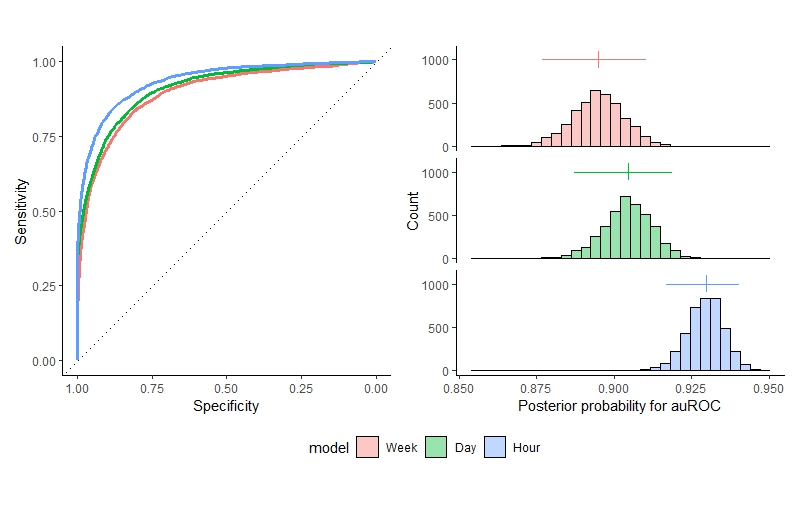

In [ ]:
knitr::include_graphics(path = "figures/ema_1.jpeg")